<a href="https://colab.research.google.com/github/kingdragonlord/titanic-ml-pipeline/blob/main/titanic_ml_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Split the dataset after making a copy
from sklearn.model_selection import train_test_split

data = df.copy()

X = data.drop('Survived', axis=1)
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Check the information on the split dataset
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          572 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        159 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


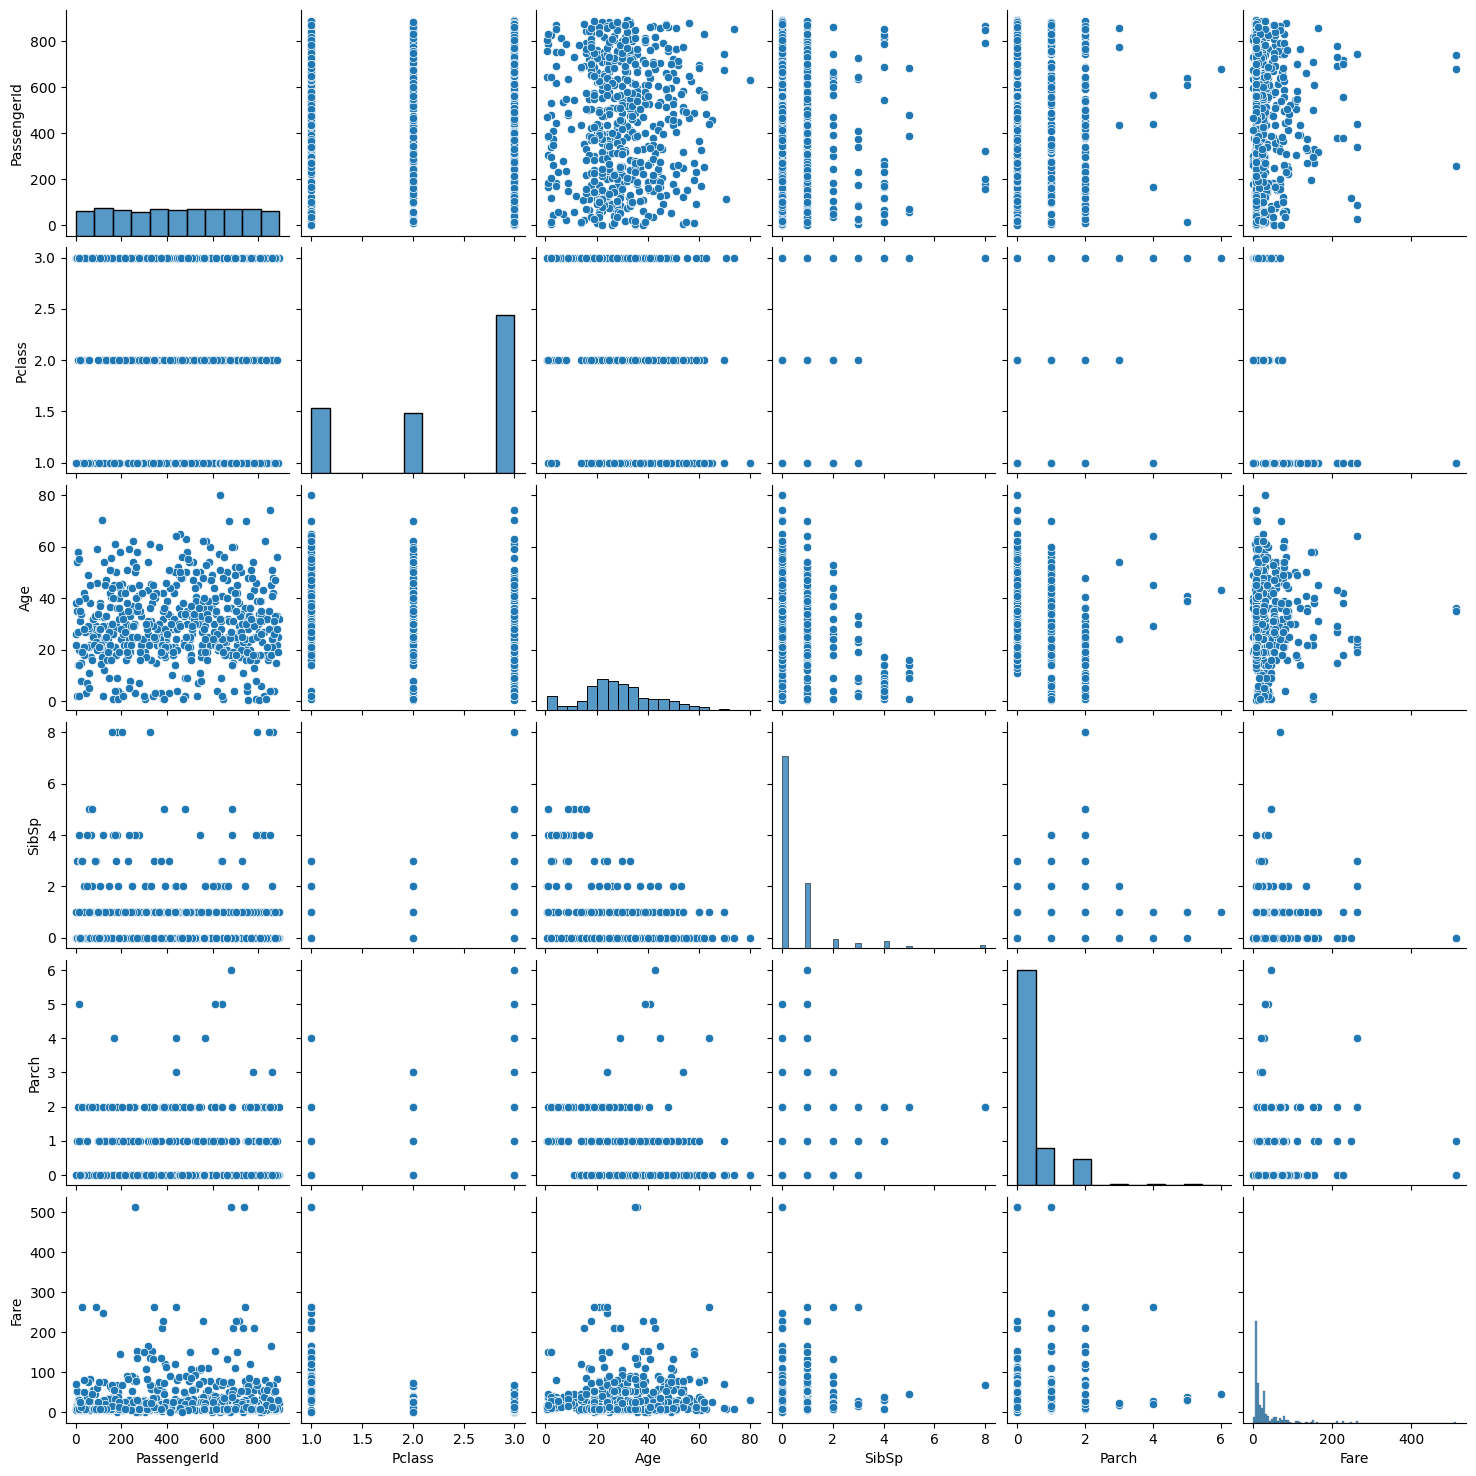

In [ ]:
sns.pairplot(data=X_train)

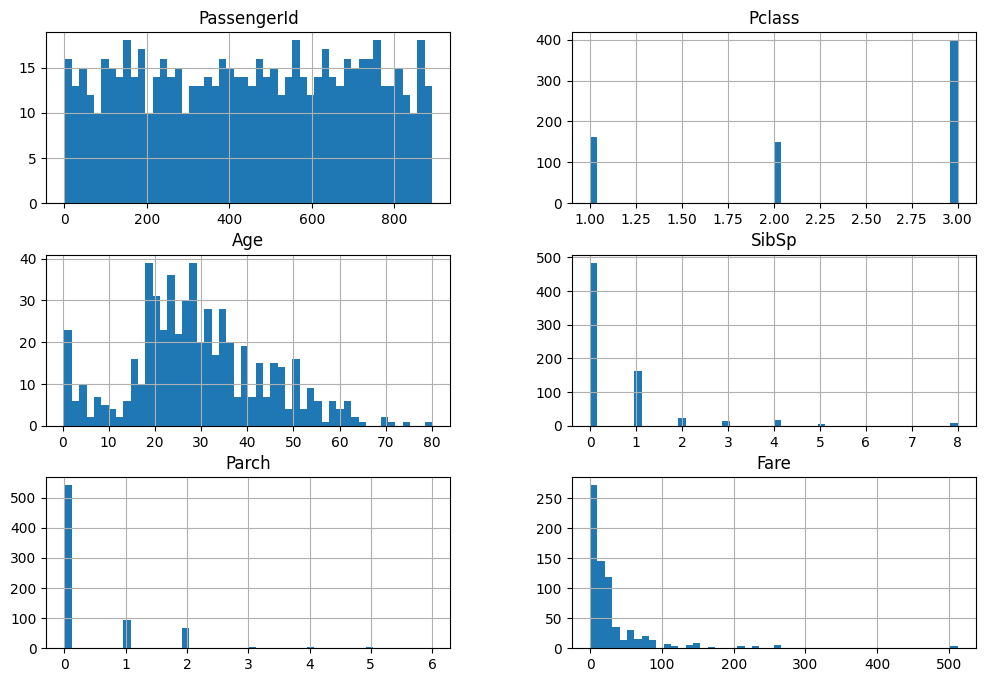

In [ ]:
X_train.hist(bins=50, figsize=(12,8))

plt.show()

In [ ]:
# Display Missing Data
X_train.isnull().sum()

,0
PassengerId,0
Pclass,0
Name,0
Sex,0
Age,140
SibSp,0
Parch,0
Ticket,0
Fare,0
Cabin,553


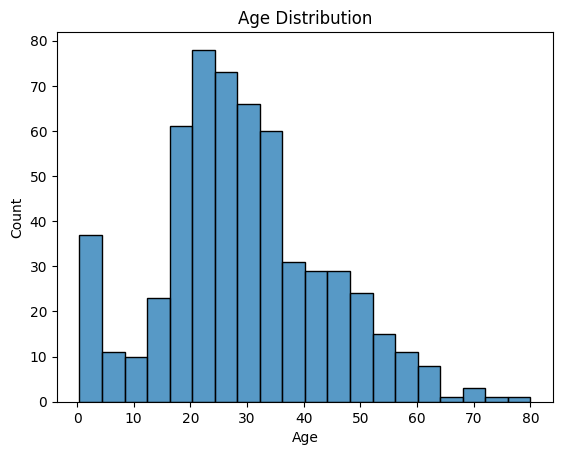

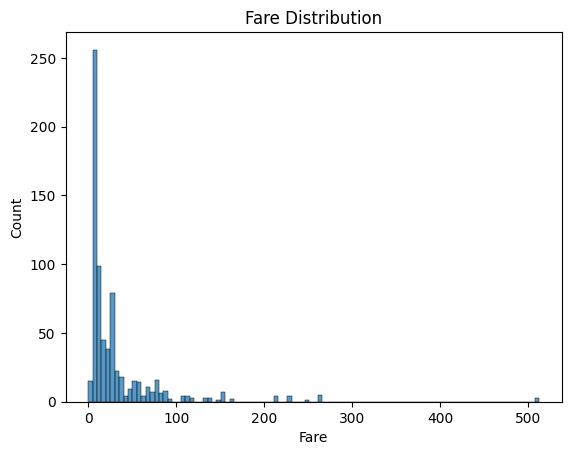

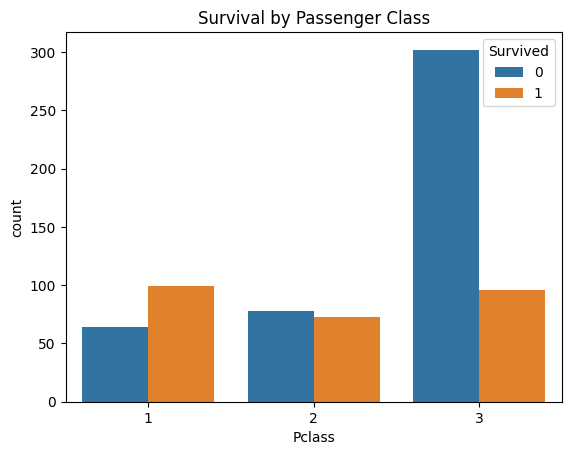

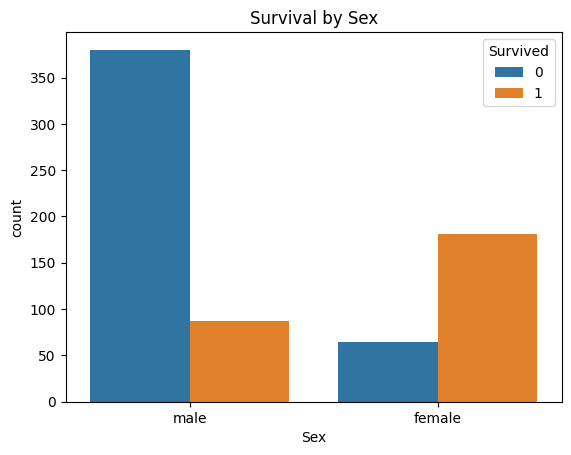

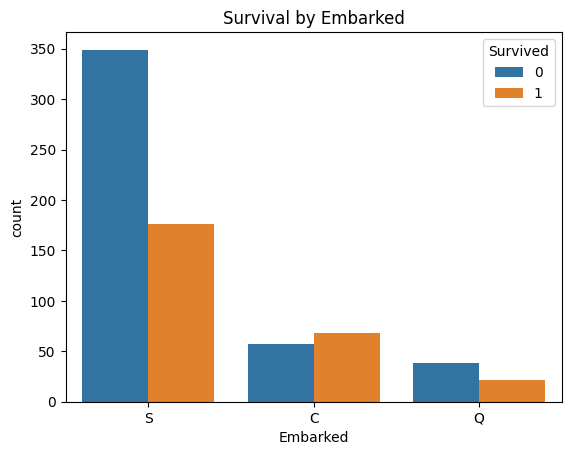

In [ ]:
# Age distribution
sns.histplot(X_train['Age'].dropna())
plt.title('Age Distribution')
plt.show()

# Fare distribution
sns.histplot(X_train['Fare'].dropna())
plt.title('Fare Distribution')
plt.show()

# Survival by Passenger Class
sns.countplot(x='Pclass', hue=y_train, data=X_train)
plt.title('Survival by Passenger Class')
plt.show()

# Survival by Sex
sns.countplot(x='Sex', hue=y_train, data=X_train)
plt.title('Survival by Sex')
plt.show()

# Survival by Embarked
sns.countplot(x='Embarked', hue=y_train, data=X_train)
plt.title('Survival by Embarked')
plt.show()


In [ ]:
# Impute missing Age with median
#X_train['Age'] = X_train['Age'].fillna(X_train['Age'].median())
#X_test['Age'] = X_test['Age'].fillna(X_train['Age'].median())

# Drop Cabin
#X_train = X_train.drop('Cabin', axis=1)
#X_test = X_test.drop('Cabin', axis=1)

# Fill missing values
#X_train['Embarked'] = X_train['Embarked'].fillna(X_train['Embarked'].mode()[0])
#X_test['Embarked'] = X_test['Embarked'].fillna(X_train['Embarked'].mode()[0])

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Numeric features
#numeric_features = ['Age', 'Fare', 'SibSp', 'Parch']

# Categorical features
#categorical_features = ['Sex', 'Embarked', 'Pclass']

# Numeric transformer
#numeric_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='median')),
#    ('scaler', StandardScaler())
#])

# Categorical transformer
#categorical_transformer = Pipeline(steps=[
#    ('imputer', SimpleImputer(strategy='most_frequent')),
#    ('onehot', OneHotEncoder(handle_unknown='ignore'))
#])

# Combine transformers
#preprocessor = ColumnTransformer(
#    transformers=[
#        ('num', numeric_transformer, numeric_features),
#        ('cat', categorical_transformer, categorical_features)
#    ])

In [ ]:
# Extract Title from Names
#for dataset in [X_train, X_test]:
    # Split at comma and take the second part
 #   dataset['Title'] = dataset['Name'].str.split(',', expand=True)[1]
    # Split at period and take the first part
  #  dataset['Title'] = dataset['Title'].str.split('.', expand=True)[0]
    # Strip whitespace
   # dataset['Title'] = dataset['Title'].str.strip()

# Simple title mapping
#title_mapping = {
 #   "Mr": "Mr",
 #   "Mrs": "Mrs",
 #   "Miss": "Miss",
 #   "Master": "Master"
#}

# for dataset in [X_train, X_test]:
#    dataset['Title'] = dataset['Title'].map(title_mapping).fillna('Rare')

In [ ]:
#X_train['Title'].unique()

In [ ]:
# Create FamilySize feature
#for dataset in [X_train, X_test]:
#   dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1

# Create IsAlone feature
#for dataset in [X_train, X_test]:
#    dataset['IsAlone'] = 0
#    dataset.loc[dataset['FamilySize'] == 1, 'IsAlone'] = 1

In [ ]:
# Bin Age into categories
#for dataset in [X_train, X_test]:
#    dataset['AgeBin'] = pd.cut(dataset['Age'], bins=[0, 12, 20, 40, 120],
#                              labels=['Child', 'Teenager', 'Adult', 'Elder'])

# Bin Fare into categories
#for dataset in [X_train, X_test]:
#    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4, labels=['Low', 'Medium', 'High', 'Very_High'])

In [ ]:
# Drop unnecessary columns
#for dataset in [X_train, X_test]:
#    dataset.drop(['Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 331 to 102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Pclass       712 non-null    int64  
 2   Name         712 non-null    object 
 3   Sex          712 non-null    object 
 4   Age          572 non-null    float64
 5   SibSp        712 non-null    int64  
 6   Parch        712 non-null    int64  
 7   Ticket       712 non-null    object 
 8   Fare         712 non-null    float64
 9   Cabin        159 non-null    object 
 10  Embarked     710 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.8+ KB


In [ ]:
# Name the features
numeric_features = ['SibSp', 'Parch', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'IsAlone']

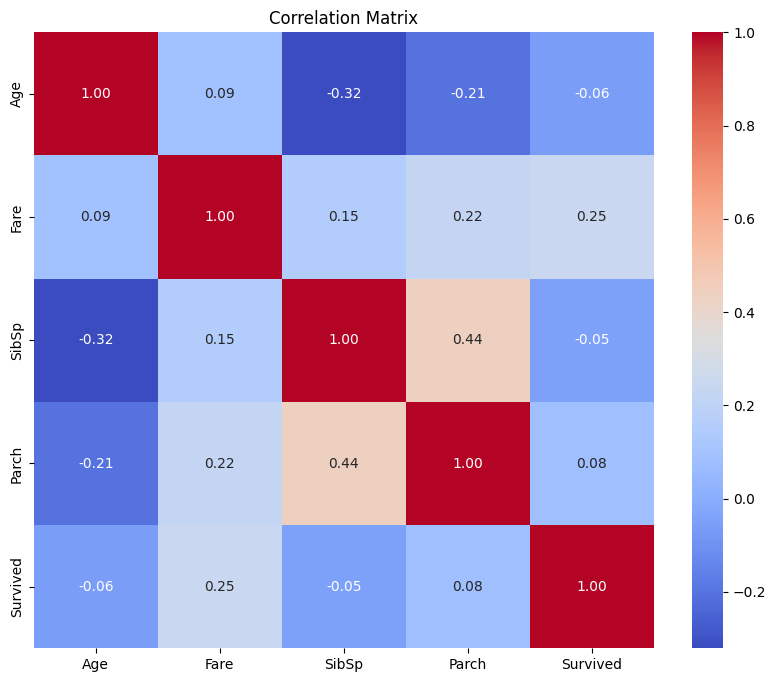

In [ ]:
# Combine X_train and y_train for correlation analysis
train_data = X_train.copy()
train_data['Survived'] = y_train

# Select numerical features
numerical_features = ['Age', 'Fare', 'SibSp', 'Parch']

# Compute correlation matrix
corr_matrix = train_data[numerical_features + ['Survived']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


In [ ]:
# Drop SibSp and Parch since its components of FamilySize, to reduce redundancy
#X_train = X_train.drop(['SibSp', 'Parch'], axis=1)
#X_test = X_test.drop(['SibSp', 'Parch'], axis=1)

# Update feature lists
#numeric_features = ['FamilySize']
#categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'IsAlone']


In [ ]:
columns_to_drop = ['Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch']

In [ ]:
# Updated numeric features
numeric_features = ['FamilySize']

# Updated categorical features
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Title', 'AgeBin', 'FareBin', 'IsAlone']

# Numeric transformer (scaling only)
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical transformer (one-hot encoding)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Updated preprocessor with new feature lists
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

##NOTES##
I observed the training set found the missing data points and imputed the missing values. I also looked at the correlation patterns and saw some positive relationships between the survival and Fare, Females, and Embarked 'S'. Then I  created a new numeric feature called FamilySize from SibSp and Parch, and a few categorical features like Title, AgeBin, FareBin, and IsAlone.

This was also the point that I went back and created the custom classes for the pipeline using the metrics I had defined above.

In [ ]:
# Implement Custom Transformers by creating custom Classes
from sklearn.base import BaseEstimator, TransformerMixin


# Missing Value Imputer:
class MissingValueImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.age_imputer = SimpleImputer(strategy='median')
        self.embarked_imputer = SimpleImputer(strategy='most_frequent')

    def fit(self, X, y=None):
        self.age_imputer.fit(X[['Age']])
        self.embarked_imputer.fit(X[['Embarked']])
        return self

    def transform(self, X):
        X = X.copy()
        X['Age'] = self.age_imputer.transform(X[['Age']]).reshape(-1)
        X['Embarked'] = self.embarked_imputer.transform(X[['Embarked']]).reshape(-1)
        return X


# Title Extractor:
class TitleExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.title_mapping = {
            "Mr": "Mr",
            "Mrs": "Mrs",
            "Miss": "Miss",
            "Master": "Master"
        }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Extract titles
        X['Title'] = X['Name'].str.extract(r',\s*([^\.]*)\.', expand=False)
        # Map titles
        X['Title'] = X['Title'].map(self.title_mapping).fillna('Rare')
        return X


# Family Size Adder:
class FamilySizeAdder(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Create 'FamilySize' feature
        X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
        return X


# Is Alone Creator:
class IsAloneCreator(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Create 'IsAlone' feature
        X['IsAlone'] = 1
        X.loc[X['FamilySize'] > 1, 'IsAlone'] = 0
        return X

# Age Binner:
class AgeBinner(BaseEstimator, TransformerMixin):
    def __init__(self, bins=None, labels=None):
        if bins is None:
            self.bins = [0, 12, 20, 40, np.inf]
        else:
            self.bins = bins
        if labels is None:
            self.labels = ['Child', 'Teenager', 'Adult', 'Elder']
        else:
            self.labels = labels

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Bin 'Age' into 'AgeBin'
        X['AgeBin'] = pd.cut(X['Age'], bins=self.bins, labels=self.labels)
        return X


# Fare Binner:
class FareBinner(BaseEstimator, TransformerMixin):
    def __init__(self, labels=None):
        if labels is None:
            self.labels = ['Low', 'Medium', 'High', 'Very_High']
        else:
            self.labels = labels

    def fit(self, X, y=None):
        # Determine bins based on quartiles from the training data
        self.bins = np.quantile(X['Fare'], [0, 0.25, 0.5, 0.75, 1])
        return self

    def transform(self, X):
        X = X.copy()
        # Bin 'Fare' into 'FareBin'
        X['FareBin'] = pd.cut(X['Fare'], bins=self.bins, labels=self.labels, include_lowest=True)
        return X


# Column Dropper:
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X.drop(self.columns_to_drop, axis=1, inplace=True)
        return X


In [ ]:
# Create a full pipeline
full_preprocessing_pipeline = Pipeline(steps=[
    ('imputer', MissingValueImputer()),
    ('title_extractor', TitleExtractor()),
    ('family_size_adder', FamilySizeAdder()),
    ('is_alone_creator', IsAloneCreator()),
    ('age_binner', AgeBinner()),
    ('fare_binner', FareBinner()),
    ('column_dropper', ColumnDropper(columns_to_drop)),
    ('feature_encoder', preprocessor)
])


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

In [ ]:
models = [
    ('kNN', KNeighborsClassifier()),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Bagging (kNN)', BaggingClassifier(estimator=KNeighborsClassifier(), n_estimators=10, random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42))
]

In [ ]:
# Define cross-validation strategy
k = 5
cv = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

In [ ]:
# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0)
}

In [ ]:
# Initialize a list to store results
results_list = []

for name, model in models:
    # Create pipeline with preprocessing and the model
    pipeline = Pipeline(steps=[
        ('preprocessing', full_preprocessing_pipeline),
        ('classifier', model)
    ])

    # Perform cross-validation
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )

    # Calculate mean scores
    accuracy = np.mean(cv_results['test_accuracy'])
    precision = np.mean(cv_results['test_precision'])
    recall = np.mean(cv_results['test_recall'])
    f1 = np.mean(cv_results['test_f1'])

    # Append results to the DataFrame
    results_list.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

# Create a DataFrame from the list
results_df = pd.DataFrame(results_list)

# Round the results to 4 decimal places
results_df = results_df.round(4)

# Display the results
print(results_df)

           Model  Accuracy  Precision  Recall  F1 Score
0            kNN    0.8258     0.7993  0.7164    0.7554
1  Decision Tree    0.7977     0.7670  0.6677    0.7122
2  Bagging (kNN)    0.8258     0.8039  0.7165    0.7551
3  Random Forest    0.8188     0.7846  0.7162    0.7473


##Notes
At this point I have created the classes, created the pipeline, passed the training data to the models and received some predictions. Now its time to do hyperparameter optimization.

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint

# Hyper parameter grids for all the models

# KNN:
knn_param_grid = {
    'classifier__n_neighbors': range(1, 31),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__p': [1, 2]  # p=1 for Manhattan, p=2 for Euclidean
}

# Decision Tree:
dt_param_grid = {
    'classifier__max_depth': range(1, 20),
    'classifier__min_samples_split': range(2, 10),
    'classifier__min_samples_leaf': range(1, 10),
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__max_features': ['auto', 'sqrt', 'log2', None]
}

# Bagging:
bagging_param_grid = {
    'classifier__n_estimators': [10, 50, 100],
    'classifier__max_samples': [0.5, 0.7, 1.0],
    'classifier__max_features': [0.5, 0.7, 1.0],
    'classifier__bootstrap': [True, False],
    'classifier__estimator__n_neighbors': range(1, 31),
    'classifier__estimator__weights': ['uniform', 'distance'],
    'classifier__estimator__p': [1, 2]
}

#Random Forest:
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 500],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__bootstrap': [True, False],
    'classifier__criterion': ['gini', 'entropy', 'log_loss'],
    'classifier__max_features': ['auto', 'sqrt', 'log2', None]
}


In [ ]:
from sklearn.model_selection import StratifiedKFold

k = 5  # Number of folds
cv_strategy = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

scoring_metric = 'accuracy'

In [ ]:
from sklearn.model_selection import GridSearchCV

# Create pipeline for KNN Classifier
knn_pipeline = Pipeline(steps=[
    ('preprocessing', full_preprocessing_pipeline),
    ('classifier', KNeighborsClassifier())
])

# Set up GridSearchCV
knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    cv=cv_strategy,
    scoring=scoring_metric,
    n_jobs=-1,
    refit='accuracy'
)

# Fit the model
knn_grid_search.fit(X_train, y_train)

print("Best parameters for kNN:", knn_grid_search.best_params_ , "Accuracy score for kNN:" , knn_grid_search.best_score_)



Best parameters for kNN: {'classifier__n_neighbors': 14, 'classifier__p': 1, 'classifier__weights': 'uniform'} Accuracy score for kNN: 0.8342657342657341


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Create pipeline for Decision Tree
dt_pipeline = Pipeline(steps=[
    ('preprocessing', full_preprocessing_pipeline),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

# Set up RandomizedSearchCV
dt_random_search = RandomizedSearchCV(
    estimator=dt_pipeline,
    param_distributions=dt_param_grid,
    n_iter=50,
    cv=cv_strategy,
    scoring=scoring_metric,
    n_jobs=-1,
    random_state=42
)

# Fit the model
dt_random_search.fit(X_train, y_train)

print("Best parameters for Decision Tree:" , dt_random_search.best_params_ , "Accuracy score for Decision Tree:" , dt_random_search.best_score_)


Best parameters for Decision Tree: {'classifier__min_samples_split': 8, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 13, 'classifier__criterion': 'log_loss'} Accuracy score for Decision Tree: 0.8286811779769525


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
25 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
11 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/pyt

In [ ]:

# Create pipeline for random bagging classifier
bagging_pipeline = Pipeline(steps=[
    ('preprocessing', full_preprocessing_pipeline),
    ('classifier', BaggingClassifier(
        estimator=KNeighborsClassifier(),
        random_state=42
    ))
])

# Set up RandomizedSearchCV
bagging_random_search = RandomizedSearchCV(
    estimator=bagging_pipeline,
    param_distributions=bagging_param_grid,
    n_iter=50,  # Number of parameter settings that are sampled
    cv=cv_strategy,
    scoring=scoring_metric,
    n_jobs=-1,
    random_state=42
)

# Fit the model
bagging_random_search.fit(X_train, y_train)

print("Best parameters for Bagging Classifier with kNN:" , bagging_random_search.best_params_ , "Best score for Bagging Classifier:" , bagging_random_search.best_score_)

Best parameters for Bagging Classifier with kNN: {'classifier__n_estimators': 50, 'classifier__max_samples': 0.7, 'classifier__max_features': 0.7, 'classifier__estimator__weights': 'uniform', 'classifier__estimator__p': 1, 'classifier__estimator__n_neighbors': 9, 'classifier__bootstrap': False} Best score for Bagging Classifier: 0.8384812370727863


In [ ]:
# Create pipeline for random forest classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessing', full_preprocessing_pipeline),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Set up RandomizedSearchCV
rf_random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param_grid,
    n_iter=50,
    cv=cv_strategy,
    scoring=scoring_metric,
    n_jobs=-1,
    random_state=42
)

# Fit the model
rf_random_search.fit(X_train, y_train)

print("Best parameters for Random Forest:" , rf_random_search.best_params_ , "Best score for Random Forest:" , rf_random_search.best_score_)

/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
70 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/pipeline.py", line 473, in fit
    self._final_estimator.fit(Xt, y, **last_step_params["fit"])
  File "/usr/local/lib/pyt

Best parameters for Random Forest: {'classifier__n_estimators': 200, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__max_depth': 30, 'classifier__criterion': 'entropy', 'classifier__bootstrap': True} Best score for Random Forest: 0.8426967398798386


##Notes
The Random forest model has the highest accuracy score out of all of the models after optimization at 84%.

In [ ]:
# Best estimator from Random Forest RandomizedSearchCV
best_rf_model = rf_random_search.best_estimator_

# Use the Test set
y_test_pred = best_rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)

# Additional metrics if needed
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       105
           1       0.79      0.73      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

Confusion Matrix:
[[91 14]
 [20 54]]
Test Accuracy: 0.8101
Test Precision: 0.7941
Test Recall: 0.7297
Test F1 Score: 0.7606


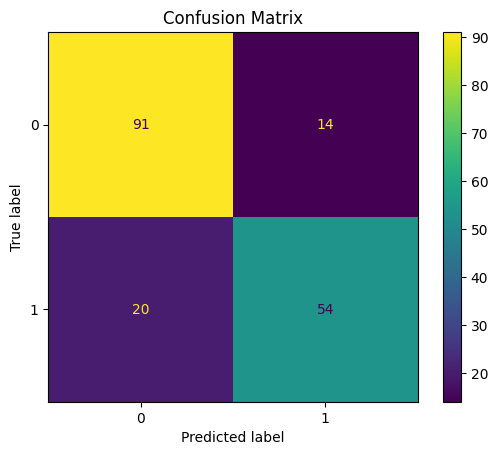

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)
plt.title('Confusion Matrix')
plt.show()

##Results
Above we can see that the tuned random forest model was 81% accurate on unseen data compared to 84% on the training data.


Below we can see that the tuned KNN Bagging Classifier performed at 80% on unseen data compared to 83% on the training data.

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       105
           1       0.79      0.72      0.75        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

Confusion Matrix:
[[91 14]
 [21 53]]
Test Accuracy: 0.8045
Test Precision: 0.7910
Test Recall: 0.7162
Test F1 Score: 0.7518


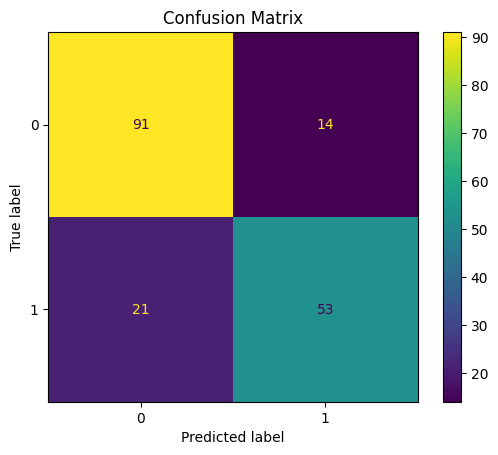

In [ ]:
# Best estimator from Bagging RandomizedSearchCV
second_best_rf_model = bagging_random_search.best_estimator_

# Use the Test set
y_test_preds = second_best_rf_model.predict(X_test)

# Classification report
print("Classification Report:")
print(classification_report(y_test, y_test_preds))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_preds)
print("Confusion Matrix:")
print(cm)

# Additional metrics if needed
test_accuracy = accuracy_score(y_test, y_test_preds)
test_precision = precision_score(y_test, y_test_preds)
test_recall = recall_score(y_test, y_test_preds)
test_f1 = f1_score(y_test, y_test_preds)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Plot confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_test_preds)
plt.title('Confusion Matrix')
plt.show()